In [36]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

import gplugins.tidy3d.materials as mat
import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp

from matplotlib.pyplot import cm


import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

core_material = td.material_library["cSi"]["Palik_Lossless"]
clad_material = td.material_library["SiO2"]["Horiba"]

## 1. Simulating Propagation Modes in SOI Waveguides

### 1. Define the SOI waveguide structure (450 nm width, 220 nm thickness).


19:57:53 CEST ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

2026-04-23 19:57:53.914 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a69bf64fd818584e.npz.


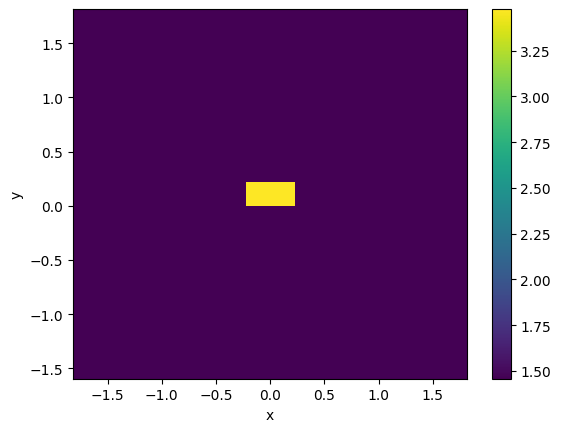

In [37]:
TE_fraction = []
deep_waveguide = gt.modes.Waveguide(
    core_width=0.45,
    core_thickness=0.22,
    core_material=core_material, #  Material of the waveguide
    clad_material=clad_material, # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=45, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()
neff = deep_waveguide.n_eff
TE_fraction = deep_waveguide.fraction_te

### 2. Simulate fundamental TE and TM modes.


Text(0.5, 1.0, 'TE Mode')

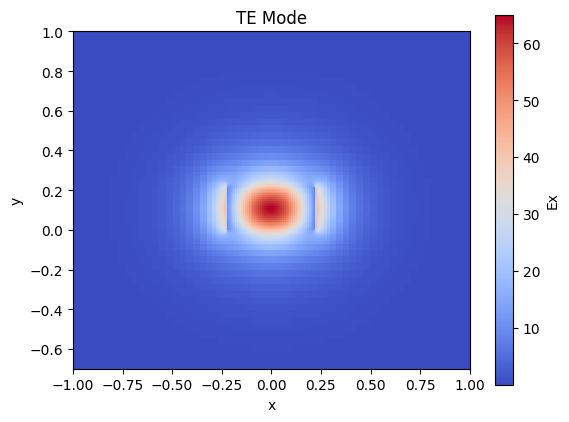

In [38]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1, 1), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('TE Mode')

Text(0.5, 1.0, 'TM Mode')

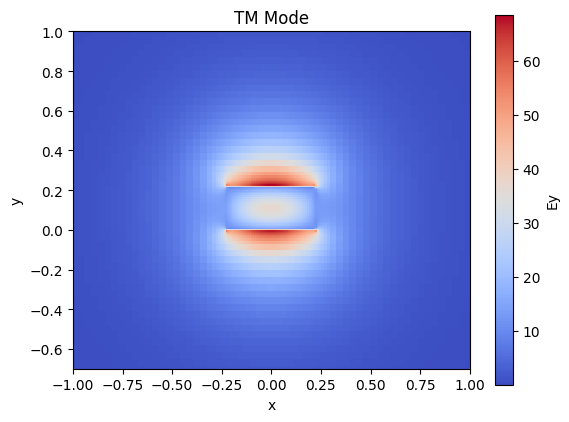

In [39]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1, 1), # Set the x and y limits
                          ylim=(-0.7, 1)) #
plt.title('TM Mode')  

In [40]:
neff=deep_waveguide.n_eff
print(f"Effective index of the fundamental TE mode: {neff[0]:.4f}")
print(f"Effective index of the fundamental TM mode: {neff[1]:.4f}")

Effective index of the fundamental TE mode: 2.3579+0.0001j
Effective index of the fundamental TM mode: 1.7509+0.0002j


In [41]:
deep_waveguide.fraction_te
#compute the fraction of the power in the core for the TE mode
#Podemos ver como el modo 0 es principalmente TE, mientras que el modo 1 es principalmente TM. Esto se refleja en los valores de la fracción de potencia en el núcleo para cada modo.

array([0.96842054, 0.07124076, 0.63805806, 0.99772795])

In [42]:
deep_waveguide.fraction_tm
#compute the fraction of the power in the core for the TM mode

array([0.03157946, 0.92875924, 0.36194194, 0.00227205])

### 3. Extract effective index (n_eff) and group index (n_g) values.


2026-04-23 19:57:54.779 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0c9e4d4230de1afd.npz.


/home/flore/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/flore/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


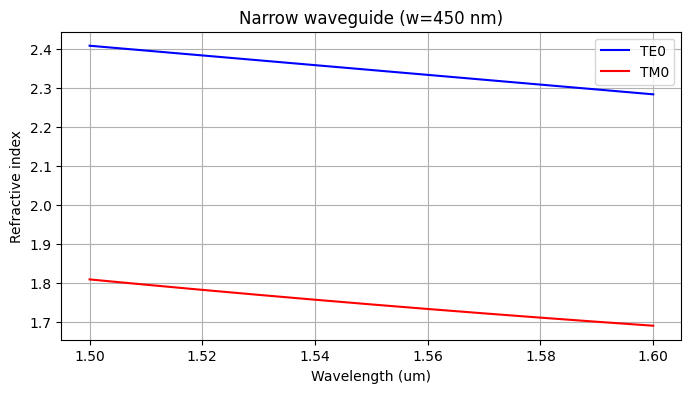

In [43]:

TE_fraction = []
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=0.45, # width
    core_thickness=0.22, # height 
    slab_thickness=0, 
    # Materials
    core_material='si', 
    clad_material='sio2', 
    # Modesolver Parameters
    wavelength=wavelength, 
    num_modes=4,
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=45, # Parameters of the grid
    cache_path='.cache/', 
    precision='double',
)

neff = deep_waveguide.n_eff
TE_fraction = deep_waveguide.fraction_te

# Los modos TE0 y TM0 son los modos 0 y 1 respectivamente
TE0 = []
TM0 = []

for i in range(len(neff)):
    TE0.append(neff[i,0])
    TM0.append(neff[i,1])

plt.figure(figsize=(8, 4))
plt.plot(wavelength, TE0, linestyle='-', color='blue', label='TE0')
plt.plot(wavelength, TM0, linestyle='-', color='red', label='TM0')
plt.xlabel('Wavelength (um)')
plt.ylabel('Refractive index')
plt.title('Narrow waveguide (w=450 nm)')
plt.legend()
plt.grid()

plt.show()

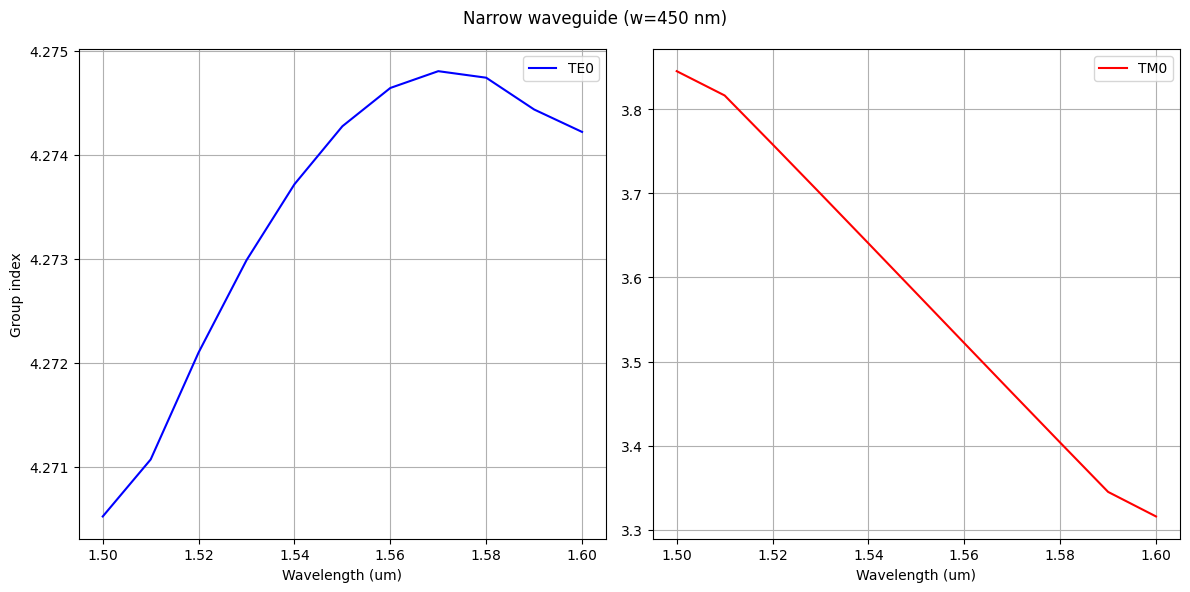

In [44]:
# Calculamos el índice de grupo
pendiente_TE = np.gradient(TE0,wavelength)
ng_TE = TE0-wavelength*pendiente_TE
pendiente_TM = np.gradient(TM0,wavelength)
ng_TM = TM0-wavelength*pendiente_TM

plt.figure(figsize=(12, 6))
plt.suptitle('Narrow waveguide (w=450 nm)')

# TE
plt.subplot(1, 2, 1)
plt.plot(wavelength, ng_TE, linestyle='-', color='blue', label='TE0')
plt.xlabel('Wavelength (um)')
plt.ylabel('Group index')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y', useOffset=False)  # ✅ desactiva notación científica

# TM
plt.subplot(1, 2, 2)
plt.plot(wavelength, ng_TM, linestyle='-', color='red', label='TM0')
plt.xlabel('Wavelength (um)')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y', useOffset=False)


plt.tight_layout()
plt.show()

## 2. Designing Directional Couplers

### 1. Simulate directional couplers in GDSFactory.


19:57:55 CEST ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

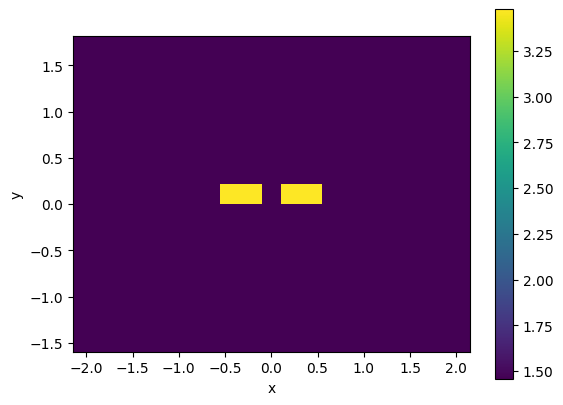

In [45]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(0.45, 0.45), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=220 * nm, # Waveguide height 
    gap=200 * nm,
    # Materials
    core_material=core_material, #  Material of the waveguide
    clad_material=clad_material, # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

2026-04-23 19:57:55.750 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_87c8c02a8f611997.npz.


Text(0.5, 1.0, 'TE Mode')

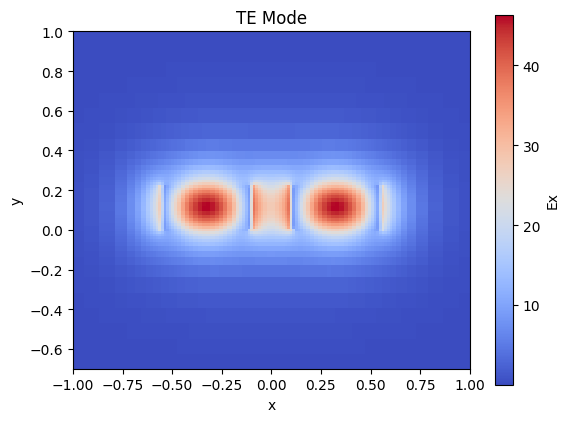

In [46]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1, 1), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('TE Mode') # You might need this later :) 

In [47]:
dcoupler_cs.fraction_te

array([0.967875  , 0.96823317, 0.05004068, 0.09721171])

Text(0.5, 1.0, 'TE Mode')

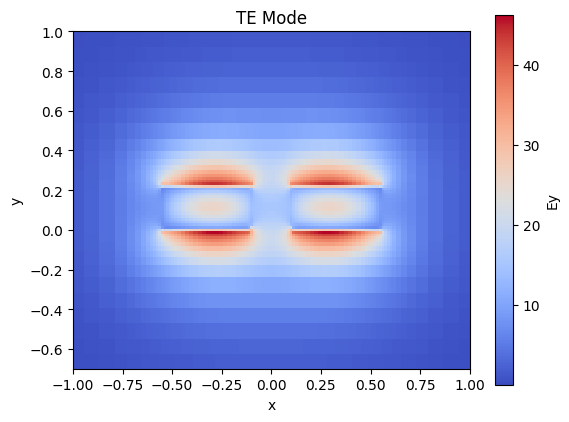

In [48]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1, 1), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('TE Mode') # You might need this later :) 

### 2. Sweep different gap values and coupling lengths.


19:57:56 CEST ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

2026-04-23 19:57:56.503 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_983769a442e872e2.npz.


              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

...

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

2026-04-23 19:57:58.312 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9b3f4df9dbc270b4.npz.


              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

2026-04-23 19:57:58.465 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9f5f1bf421949071.npz.


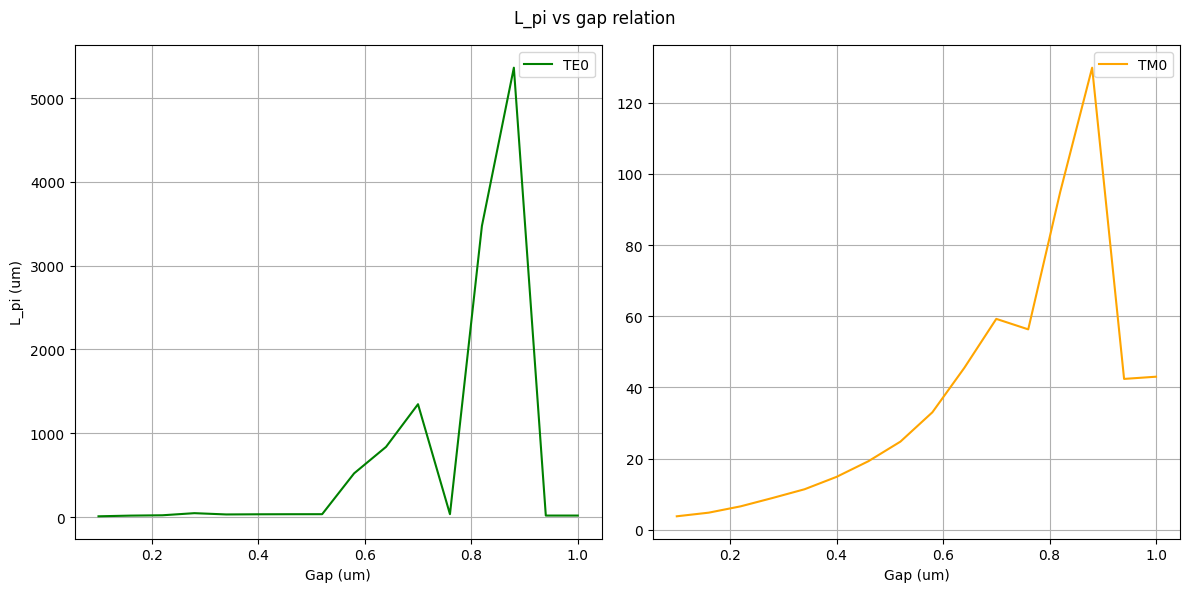

In [49]:
# Parámetros a barrer
gap = np.linspace(0.1,1,16)
TE_fraction = []
coupler_neff = []

for g in gap:
    coupler = gt.modes.WaveguideCoupler(
        core_width=(0.45, 0.45),
        slab_thickness=0 * nm,
        core_thickness=220 * nm,
        gap=g,
        core_material=core_material,
        clad_material=clad_material,
        wavelength=lambda_c,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )
    TE_fraction.append(coupler.fraction_te)
    coupler_neff.append(coupler.n_eff)

delta_TE = []
delta_TM = []

for i in range(len(coupler_neff)):
    delta_TE.append(np.abs(coupler_neff[i][0]-coupler_neff[i][1])) #estamos haciendo neven - nodd 
    delta_TM.append(np.abs(coupler_neff[i][2]-coupler_neff[i][3]))
# Guardamos los valores TE y TM (TE: 0 y 1, TM: 2 y 3) y sacamos Lpi de TE y TM a partir de la fórmula Lpi = lambda/(2*abs(neven-nodd))
Lpi_TE =[]
Lpi_TM = []

for i in range(len(coupler_neff)):
    Lpi_TE.append(1/2*(lambda_c/delta_TE[i])) 
    Lpi_TM.append(1/2*(lambda_c/delta_TM[i]))

# Plot
plt.figure(figsize=(12, 6))
plt.suptitle('L_pi vs gap relation')

# para modo TE
plt.subplot(1, 2, 1)
plt.plot(gap, Lpi_TE, linestyle='-', color='green', label='TE0')
plt.xlabel('Gap (um)')
plt.ylabel('L_pi (um)')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y', useOffset=False)  

# para modo TM
plt.subplot(1, 2, 2)
plt.plot(gap, Lpi_TM, linestyle='-', color='orange', label='TM0')
plt.xlabel('Gap (um)')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y', useOffset=False)


plt.tight_layout()
plt.show()

Vemos que en TE0 a partir de 0.5um Lpi aumenta mucho, por lo que querremos mantener este gap pequeño. Mientras en TM0 aunque Lpi aumenta a medida que aumenta el gap, no lo hace tan bruscamente.

### 3. Extract coupling coefficients (e.g., 0.5, 0.3, 0.23, etc.).

Tenemos que averiguar que Lc (longitud de acoplo) necesitamos para conseguir constantes de acoplo de 0.5, 0.3, 0.23...

In [50]:
gap = 0.45

coupler = gt.modes.WaveguideCoupler(
    core_width=(0.45, 0.45),
    slab_thickness=0 * nm,
    core_thickness=220 * nm,
    gap=gap,
   core_material=core_material,
    clad_material=clad_material,
    wavelength=lambda_c,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20
    )
TE_fraction=coupler.fraction_te
coupler_neff=coupler.n_eff
    
#Se calcula Lpi para TE y TM a partir de la fórmula Lpi = lambda/(2*abs(neven-nodd))
Lpi_TE=1/2*(lambda_c/np.abs(coupler_neff[0]-coupler_neff[1]))
Lpi_TM=1/2*(lambda_c/np.abs(coupler_neff[2]-coupler_neff[3]))

#Finalmente se obtiene Lc a partir de la fórmula Lc = arcsin(sqrt(k))*2*Lpi/pi para cada modo y cada k
#Para k=0.5
k_05 = 0.5
L_c_TE = np.arcsin(np.sqrt(k_05))*2*Lpi_TE/np.pi
L_c_TM = np.arcsin(np.sqrt(k_05))*2*Lpi_TM/np.pi
print(f' para k = {k_05}')
print(f'Longitud de acoplo modo TE = {L_c_TE:.3f} um')
print(f'Longitud de acoplo modo TM = {L_c_TM:.3f} um')

# parak = 0.3
k_03 = 0.3
L_c_0_3_TE = np.arcsin(np.sqrt(k_03))*2*Lpi_TE/np.pi
L_c_0_3_TM = np.arcsin(np.sqrt(k_03))*2*Lpi_TM/np.pi

print(f' para k = {k_03}')
print(f'Longitud de acoplo modo TE = {L_c_0_3_TE:.3f} um')
print(f'Longitud de acoplo modo TM = {L_c_0_3_TM:.3f} um')

# para k = 0.23
k_023 = 0.23
L_c_0_23_TE = np.arcsin(np.sqrt(k_023))*2*Lpi_TE/np.pi
L_c_0_23_TM = np.arcsin(np.sqrt(k_023))*2*Lpi_TM/np.pi
print(f' para k = {k_023}')
print(f'Longitud de acoplo modo TE = {L_c_0_23_TE:.3f} um')
print(f'Longitud de acoplo modo TM = {L_c_0_23_TM:.3f} um')

# para k =0.17
k_017 = 0.17
L_c_0_17_TE = np.arcsin(np.sqrt(k_017))*2*Lpi_TE/np.pi
L_c_0_17_TM = np.arcsin(np.sqrt(k_017))*2*Lpi_TM/np.pi
print(f' para k = {k_017}')
print(f'Longitud de acoplo modo TE = {L_c_0_17_TE:.3f} um')
print(f'Longitud de acoplo modo TM = {L_c_0_17_TM:.3f} um')

# para k = 0.05
k_005 = 0.05
L_c_0_05_TE = np.arcsin(np.sqrt(k_005))*2*Lpi_TE/np.pi
L_c_0_05_TM = np.arcsin(np.sqrt(k_005))*2*Lpi_TM/np.pi
print(f' para k = {k_005}')
print(f'Longitud de acoplo modo TE = {L_c_0_05_TE:.3f} um')
print(f'Longitud de acoplo modo TM = {L_c_0_05_TM:.3f} um')

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

              ERROR: Missing spatial profiles of 'permittivity' or              
              'eps_dataset'.                                                    

2026-04-23 19:57:58.854 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_36002fbf8691a5bd.npz.
 para k = 0.5
Longitud de acoplo modo TE = 91.763 um
Longitud de acoplo modo TM = 9.729 um
 para k = 0.3
Longitud de acoplo modo TE = 67.723 um
Longitud de acoplo modo TM = 7.180 um
 para k = 0.23
Longitud de acoplo modo TE = 58.439 um
Longitud de acoplo modo TM = 6.196 um
 para k = 0.17
Longitud de acoplo modo TE = 49.654 um
Longitud de acoplo modo TM = 5.264 um
 para k = 0.05
Longitud de acoplo modo TE = 26.348 um
Longitud de acoplo modo TM = 2.793 um


## 3. Cascaded MZI Filter and SAX Model

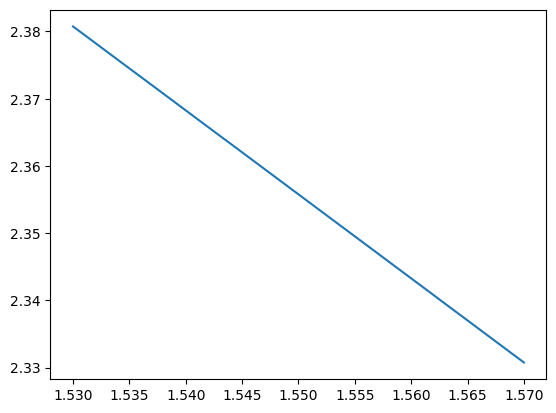

In [51]:
wvl_orig = np.linspace(1.53, 1.57, 41)
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

neff_TE = SOI[:, 3]
neff_TM = SOI[:, 5]

plt.plot(wvl_orig,neff_TE)

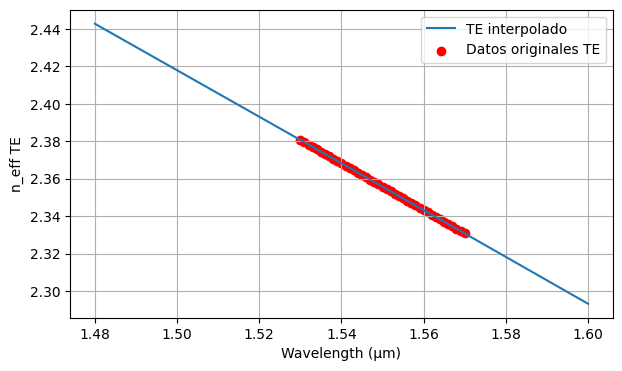

In [52]:
from scipy.interpolate import interp1d

# Datos originales
wvl_orig = np.linspace(1.53, 1.57, 41)
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

neff_TE = SOI[:, 3]
neff_TM = SOI[:, 5]

# Interpolación lineal con extrapolación
interp_neffu_TE = interp1d(
    wvl_orig, neff_TE,
    kind='linear',
    fill_value="extrapolate",
    bounds_error=False
)

interp_neffu_TM = interp1d(
    wvl_orig, neff_TM,
    kind='linear',
    fill_value="extrapolate",
    bounds_error=False
)

# Nuevo eje
wvl = np.linspace(1.48, 1.60, 1000)

# Interpolados
TE0 = interp_neffu_TE(wvl)
TM0 = interp_neffu_TM(wvl)

# Calculamos el índice de grupo
pendiente_TE = np.gradient(TE0,wvl)
ng_TE = TE0-wvl*pendiente_TE
# Plot opcional
plt.figure(figsize=(7,4))
plt.plot(wvl, TE0, label="TE interpolado")
plt.scatter(wvl_orig, neff_TE, color='red', label="Datos originales TE")
plt.xlabel("Wavelength (µm)")
plt.ylabel("n_eff TE")
plt.grid(True)
plt.legend()
plt.show()

### 3.1 Extract the S-matrix from individual components.

Modelamos una guía de onda y un acoplador con sus respectivas S-matrix

In [53]:
def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

### 3.2. Define two arms of the MZI with different lengths.


In [62]:
s1,info = sax.circuit(
    netlist={
        'instances':{
            'coup1':'coupler',
            'coup2':'coupler',
            'coup3':'coupler',
            'coup4':'coupler',
            'wgu1':'waveguide',
            'wgu2':'waveguide',
            'wgu3':'waveguide',
            'wgd1':'waveguide',
            'wgd2':'waveguide',
            'wgd3':'waveguide',
        },
        "connections": {
            "coup1,out0": "wgu1,in0",
            "coup1,out1": "wgd1,in0",
            'wgu1,out0':'coup2,in0',
            'wgd1,out0':'coup2,in1',

            "coup2,out0": "wgu2,in0",
            "coup2,out1": "wgd2,in0",
            'wgu2,out0':'coup3,in0',
            'wgd2,out0':'coup3,in1',

            "coup3,out0": "wgu3,in0",
            "coup3,out1": "wgd3,in0",
            'wgu3,out0':'coup4,in0',
            'wgd3,out0':'coup4,in1',

        },
        # Definimos los puertos de entrada y de salida generales del sistema
        "ports": {
            "in0": "coup1,in0",
            "in1": "coup1,in1",
            "out0": "coup4,out0",
            "out1": "coup4,out1",
        },
    },
    models={
        # A los componentes que hemos definido como coupler y waveguide, les asignamos las propiedades de las funciones definidas en la celda anterior
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

### 3.3. Implement the phase condition as per Equation (1).


In [66]:
neff=2.35 #Es aproximadamente el valor de neff que hemos obtenido para el modo TE0, puede calcularse de los apartados anteriores, se ha sacado de la grafica del apartado 1.3
L = 10.0  # longitud base
m=40 # como el desfase se repite cada 2pi, podemos añadir un múltiplo de 2pi a la diferencia de fase para obtener el mismo resultado, esto nos permite obtener un delta_L más grande y por tanto, con mayor FSR.
delta_phi = np.pi / 2 +2*np.pi*m    #Diferencia de fase que queremos obtener entre los dos brazos del MZI para obtener interferencia destructiva en la salida 0 y constructiva en la salida 1. Esto se puede cambiar para obtener diferentes resultados.

delta_L = (delta_phi * lambda_c) / (2 * np.pi * neff) # Calculamos el delta_L que tenemos que añadir a uno de los brazos para obtener la diferencia de fase deseada
settings = {
    "wvgu": {"length": L, "neff": neff},
    "wvgd": {"length": L + delta_L, "neff": neff},
}
S = s1(wl=1.55, **settings)
print(delta_L)

26.54787234042553


### 3.4. Simulate transmission spectrum and confirm free spectral range (FSR).


In [64]:
wvl = np.linspace(1.48,1.6,len(TE0))
# Calculamos el valor de m para que la funcion de transferencia presente un FSR de 40 nm. (Esto lo hemos hecho después de centrar el especto en 1540nm con una potencia de 0.5)(ver celda siguiente)
FSR = 40e-3
m = 3*wvl[500]*TE0[500]/(ng_TE[500]*FSR)-1/4

l2 = 10
print(m)

63.462895638435384


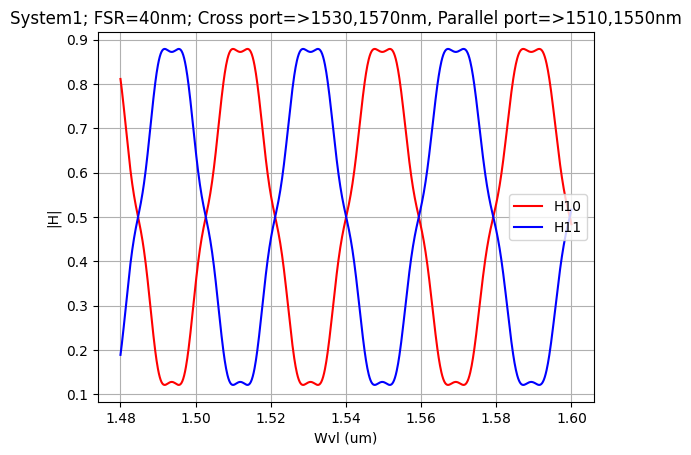

l1 = 24.469451255975137
delta_phi = 0.3251562079994413


In [63]:
wvl = np.linspace(1.48,1.6,len(TE0))
m = 65 #valor seleccionado para tener un FSR visible en la gráfica, ronda los 40 nm.
l2 = 10
# Forma de desplazar el espectro un desfase phi (en este caso desplazamos pi porque se nos iban los canales por los puertos contrarios)
delta_phi_despl = np.pi/(2*np.pi*TE0[500])*wvl[500]
l1 = wvl[500]/(3*TE0[500])*m+wvl[500]/(12*TE0[500])+l2+delta_phi_despl #wvl[500] y TE0[500] hacer referencia al valor de longitud de onda de 1540 nm.
k1 = 0.5
k2 = 0.17
k3 = 0.23
k4 = 0.05

s1_test = s1(
            coup1 = {'coupling': k1},
            coup2 = {'coupling': k2},
            coup3 = {'coupling': k3},
            coup4 = {'coupling': k4},
            wgu1={"length": l1, "neff": TE0,"wl": wvl,'loss':0},
            wgu2={"length": 2*l2, "neff": TE0,"wl": wvl,'loss':0},
            wgu3={"length": 2*l2, "neff": TE0,"wl": wvl,'loss':0},
            wgd1={"length": l2, "neff": TE0,"wl": wvl,'loss':0},
            wgd2={"length": 2*l1, "neff": TE0,"wl": wvl,'loss':0},
            wgd3={"length": 2*l1, "neff": TE0,"wl": wvl,'loss':0},
)

# Analizamos la respuesta en ambos puertos de salida cuando la energía entra por el puerto de abajo (puerto 1)
h10 = s1_test["in1", "out0"]
h11 = s1_test["in1", "out1"]

H11 = np.abs(h11)**2
H10 = np.abs(h10)**2

plt.plot(wvl, H10, linestyle='-', color='red', label='H10')
plt.plot(wvl, H11, linestyle='-', color='blue', label='H11')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title(f'System1; FSR=40nm; Cross port=>1530,1570nm, Parallel port=>1510,1550nm')
plt.legend()
plt.grid(True)

plt.show()
print(f'l1 = {l1}')
print(f'delta_phi = {delta_phi_despl}')

### 3.5. Create SAX model connecting multiple MZIs in series using the designed directional couplers

In [67]:
s2,info = sax.circuit(
    netlist={
        'instances':{
            'coup1':'coupler',
            'coup2':'coupler',
            'coup3':'coupler',
            'wgu1':'waveguide',
            'wgu2':'waveguide',
            'wgd1':'waveguide',
            'wgd2':'waveguide',
        },
        "connections": {
            "coup1,out0": "wgu1,in0",
            "coup1,out1": "wgd1,in0",
            'wgu1,out0':'coup2,in0',
            'wgd1,out0':'coup2,in1',

            "coup2,out0": "wgu2,in0",
            "coup2,out1": "wgd2,in0",
            'wgu2,out0':'coup3,in0',
            'wgd2,out0':'coup3,in1',
        },
        # Definimos los puertos de entrada y de salida generales del sistema
        "ports": {
            "in0": "coup1,in0",
            "in1": "coup1,in1",
            "out0": "coup3,out0",
            "out1": "coup3,out1",
        },
    },
    models={
        # A los componentes que hemos definido como coupler y waveguide, les asignamos las propiedades de las funciones definidas en la celda anterior
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

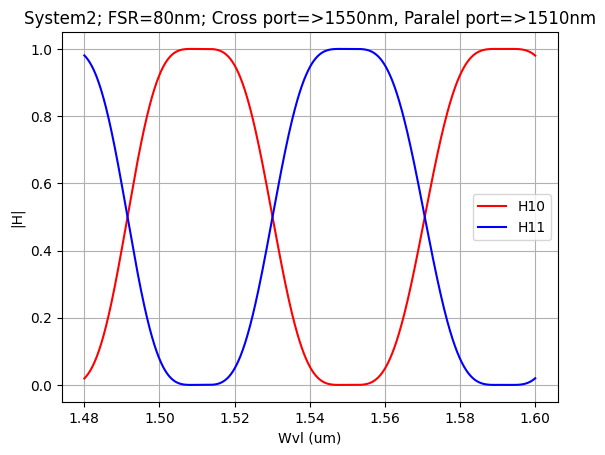

16.909297242827936


In [69]:
# Buscamos landa = 1530nm para centrar el espectro
wvl[417]
# Hemos vuelto a calcular el valor de m necesario para obtener un FSR de 80nm y dejar que la función de transferencia esté centrada en lambda = 1530 nm (ver explicación en la siguiente celda)
FSR = 80e-3
m = wvl[417]*TE0[417]/(ng_TE[417]*FSR)-1/4
m = 10
# En este caso hemos repetido lo mismo que para el s1. Como queremos que la funcion de transferencia para 1510 sea maxima cuando para 1550 sea mínima y viceversa,
# hemos definido de nuevo la longitud de onda central a 1510 y 1550 y hemos fijado que queremos que su valor de potencia sea 0.5 (en 1530, la potencia de salida será 0.5 en ambos puertos de salida)
l1=10
delta_phi_despl = np.pi/(2*np.pi*TE0[417])*wvl[417]
l2=m*wvl[417]/TE0[417]+wvl[417]/(4*TE0[417])+l1+delta_phi_despl
k1 = 0.5
k2 = 0.3
k3 = 0.05

s2_test1 = s2(
            coup1 = {'coupling': k1},
            coup2 = {'coupling': k2},
            coup3 = {'coupling': k3},
            wgu1={"length": l1, "neff": TE0,"wl": wvl,'loss':0},
            wgu2={"length": 2*l2, "neff": TE0,"wl": wvl,'loss':0},
            wgd1={"length": l2, "neff": TE0,"wl": wvl,'loss':0},
            wgd2={"length": 2*l1, "neff": TE0,"wl": wvl,'loss':0},
)

# Analizamos la respuesta en ambos puertos de salida cuando la energía entra por el puerto de abajo (puerto 1)
h10 = s2_test1["in1", "out0"]
h11 = s2_test1["in1", "out1"]

H11 = np.abs(h11)**2
H10 = np.abs(h10)**2

plt.plot(wvl, H10, linestyle='-', color='red', label='H10')
plt.plot(wvl, H11, linestyle='-', color='blue', label='H11')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title(f'System2; FSR=80nm; Cross port=>1550nm, Paralel port=>1510nm')
plt.legend()
plt.grid(True)

plt.show()

print(l2)

### 3.6.Validate spectral alignment of outputs (Achieve transmission spectrum as shownin Figure 6(a) ).

In [70]:
# Definimos s1 y s2 como funciones para poder pasarles datos de entrada cuando los instanciemos
def s1_func(wl=1.55, neff=1.6072,loss=0.0, l1=10.0, l2=10.0, k1 = 0.5,k2=0.3,k3=0.17,k4=0.05) -> sax.SDict:
    s1_test = s1(
            coup1 = {'coupling': k1},
            coup2 = {'coupling': k2},
            coup3 = {'coupling': k3},
            coup4 = {'coupling': k4},
            wgu1={"length": l1, "neff": TE0,"wl": wvl,'loss':0},
            wgu2={"length": 2*l2, "neff": TE0,"wl": wvl,'loss':0},
            wgu3={"length": 2*l2, "neff": TE0,"wl": wvl,'loss':0},
            wgd1={"length": l2, "neff": TE0,"wl": wvl,'loss':0},
            wgd2={"length": 2*l1, "neff": TE0,"wl": wvl,'loss':0},
            wgd3={"length": 2*l1, "neff": TE0,"wl": wvl,'loss':0},
    )

    # Analizamos la respuesta en ambos puertos de salida cuando la energía entra por el puerto de abajo (puerto 1)
    h10 = s1_test["in1", "out0"]
    h11 = s1_test["in1", "out1"]
    h00 = s1_test["in0", "out0"]
    h01= s1_test["in0", "out1"]

    respuesta_s1=sax.reciprocal(
        {
            ("in0", "out0"): h00,
            ("in0", "out1"): h01,
            ("in1", "out0"): h10,
            ("in1", "out1"): h11,
        }           
    )
    return respuesta_s1
# s2
def s2_func(wl=1.55, neff=1.6072,loss=0.0, l1=10.0, l2=10.0, k1 = 0.5,k2=0.3,k3=0.17) -> sax.SDict:
    s2_test = s2(
        coup1 = {'coupling': k1},
        coup2 = {'coupling': k2},
        coup3 = {'coupling': k3},
        wgu1={"length": l1, "neff": TE0,"wl": wvl,'loss':0},
        wgu2={"length": 2*l2, "neff": TE0,"wl": wvl,'loss':0},
        wgd1={"length": l2, "neff": TE0,"wl": wvl,'loss':0},
        wgd2={"length": 2*l1, "neff": TE0,"wl": wvl,'loss':0},
)

    # Analizamos la respuesta en ambos puertos de salida cuando la energía entra por el puerto de abajo (puerto 1)
    h10 = s2_test["in1", "out0"]
    h11 = s2_test["in1", "out1"]
    h00 = s2_test["in0", "out0"]
    h01= s2_test["in0", "out1"]

    respuesta_s2=sax.reciprocal(
        {
            ("in0", "out0"): h00,
            ("in0", "out1"): h01,
            ("in1", "out0"): h10,
            ("in1", "out1"): h11,
        }           
    )
    return respuesta_s2

In [71]:
system,info = sax.circuit(
    netlist={
        "instances": {
            "s1_1": "s1",
            "s1_2": "s1",
            "s1_3": "s1",
            "s2_1": "s2",
            "s2_4": "s2",
            "s2_2": "s2",
            "s2_3": "s2",
            "s2_5": "s2",
            "s2_6": "s2",
        },
        "connections": {
            # Stage1
            "s1_1,out0": "s1_2,in1",
            "s1_1,out1": "s1_3,in1",
            # Stage2
            "s1_2,out0": "s2_1,in1",
            "s1_3,out1": "s2_4,in0",
            # Stage3
                # Upper stage
            "s2_1,out0": "s2_2,in1",
            "s2_1,out1": "s2_3,in0",
                # Down stage
            "s2_4,out0": "s2_5,in1",
            "s2_4,out1": "s2_6,in0",
        },
        "ports": {
            "in0": "s1_1,in0",
            "in1": "s1_1,in1",
            "out0": "s2_2,out0",
            "out1": "s2_3,out0",
            "out2": "s2_5,out1",
            "out3": "s2_6,out1",

        },
    },
    models = {
    "s1": s1_func,
    "s2": s2_func,
    },
)

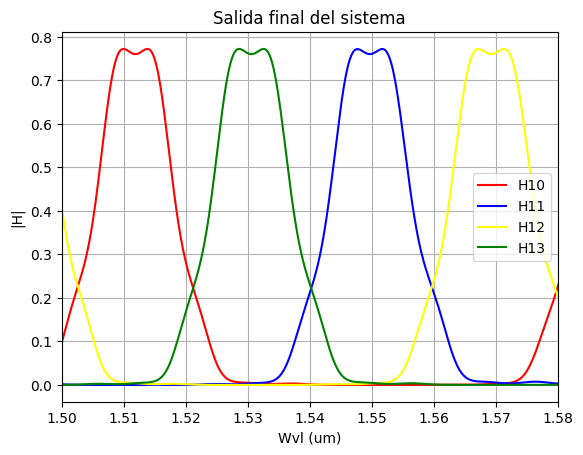

In [72]:
# S1
m1 = 65
l2_s1 = 10
delta_phi_despl_s1 = np.pi/(2*np.pi*TE0[500])*wvl[500]
l1_s1 = wvl[500]/(3*TE0[500])*m1+wvl[500]/(12*TE0[500])+l2_s1+delta_phi_despl_s1
k_s1 = [0.5,0.17,0.23,0.05]
# S2
m2 = 10
l1_s2=5
delta_phi_despl_s2_up = np.pi/(2*np.pi*TE0[583])*wvl[583]
delta_phi_despl_s2_b = np.pi/(4*np.pi*TE0[417])*wvl[417] #Se aplica solo a los s2 que se encuentran en el brazo de abajo (s2_4,5,6)
l2_s2=m2*wvl[417]/TE0[417]+wvl[417]/(4*TE0[417])+l1_s2+delta_phi_despl_s2_up
k_s2 = [0.5,0.3,0.05]

system_test = system(
    s1_1={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s1,'l2':l2_s1,'k1':k_s1[0],'k2':k_s1[1],'k3':k_s1[2],'k4':k_s1[3]},
    s1_2={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s1,'l2':l2_s1,'k1':k_s1[0],'k2':k_s1[1],'k3':k_s1[2],'k4':k_s1[3]},
    s1_3={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s1,'l2':l2_s1,'k1':k_s1[0],'k2':k_s1[1],'k3':k_s1[2],'k4':k_s1[3]},
    # Upper arm
    s2_1={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s2,'l2':l2_s2,'k1':k_s2[0],'k2':k_s2[1],'k3':k_s2[2]},
    s2_2={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s2,'l2':l2_s2,'k1':k_s2[0],'k2':k_s2[1],'k3':k_s2[2]},
    s2_3={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s2,'l2':l2_s2,'k1':k_s2[0],'k2':k_s2[1],'k3':k_s2[2]},
    # Down arm
    s2_4={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s2,'l2':l2_s2+delta_phi_despl_s2_b,'k1':k_s2[0],'k2':k_s2[1],'k3':k_s2[2]},
    s2_5={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s2,'l2':l2_s2+delta_phi_despl_s2_b,'k1':k_s2[0],'k2':k_s2[1],'k3':k_s2[2]},
    s2_6={'wl':wvl,'neff':TE0,'loss':0,'l1':l1_s2,'l2':l2_s2+delta_phi_despl_s2_b,'k1':k_s2[0],'k2':k_s2[1],'k3':k_s2[2]},
    )

# Analizamos la respuesta en ambos puertos de salida cuando la energía entra por el puerto de abajo (puerto 1)
h10 = system_test["in1", "out0"]
h11 = system_test["in1", "out1"]
h12 = system_test["in1", "out2"]
h13 = system_test["in1", "out3"]

H11 = np.abs(h11)**2
H10 = np.abs(h10)**2
H12 = np.abs(h12)**2
H13 = np.abs(h13)**2

plt.plot(wvl, H10, linestyle='-', color='red', label='H10')
plt.plot(wvl, H11, linestyle='-', color='blue', label='H11')
plt.plot(wvl, H12, linestyle='-', color='yellow', label='H12')
plt.plot(wvl, H13, linestyle='-', color='green', label='H13')

plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title(f'Salida final del sistema')
plt.xlim(1.5,1.58)
plt.legend()
plt.grid(True)

plt.show()